In [66]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

In [67]:
train = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')
test = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

In [68]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [69]:
# linear relationship
smf.ols('count ~ temp', train).fit().params

Intercept    6.046213
temp         9.170540
dtype: float64

In [70]:
# simple linear regression model
smf.ols('count ~ C(season)', train).fit().params

Intercept         116.343261
C(season)[T.2]     98.908111
C(season)[T.3]    118.073863
C(season)[T.4]     82.645034
dtype: float64

In [71]:
train['year'] = train['datetime'].str[0:4] # extract first 4 characters to make year column
train['month'] = train['datetime'].str[5:7] # extract characters 5:7
train['hour'] = train['datetime'].str[11:13] # extract characters 11:13

In [72]:
train['month'].value_counts()

month
05    912
06    912
07    912
08    912
12    912
10    911
11    911
04    909
09    909
02    901
03    901
01    884
Name: count, dtype: int64

In [73]:
train['day'] = pd.to_datetime(train['datetime']).dt.day_name()
train['day'].value_counts()

day
Saturday     1584
Sunday       1579
Thursday     1553
Monday       1551
Wednesday    1551
Tuesday      1539
Friday       1529
Name: count, dtype: int64

In [74]:
smf.ols('np.log(count) ~ temp',train).fit().params

Intercept    3.106903
temp         0.071458
dtype: float64

In [75]:
smf.ols('np.log(count) ~ temp*humidity + I(temp**2) + I(temp**3)',train).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          np.log(count)   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.248
Method:                 Least Squares   F-statistic:                     717.4
Date:                Mon, 09 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:33:31   Log-Likelihood:                -18229.
No. Observations:               10886   AIC:                         3.647e+04
Df Residuals:                   10880   BIC:                         3.651e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         2.7696      0.169     16.408      0.000       2.439       3.100
temp              0.2785      0.025     11.214      0.000       0.230       0.327
humidity         -0.0138      0.002     -6.729      0.000      -0.018      -0.010
temp:humidity    -0.0006      0.000     -5.938      0.000      -0.001      -0.000
I(temp ** 2)     -0.0062      0.001     -4.434      0.000      -0.009      -0.003
I(temp ** 3)   5.329e-05   2.29e-05      2.324      0.020    8.34e-06    9.82e-05
==============================================================================
Omnibus:                     1139.918   Durbin-Watson:                   0.299
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1533.126
Skew:                          -0.872   Prob(JB):                         0.00
Kurtosis:                       3.579   Cond. No.                     2.26e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.26e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

<Axes: xlabel='temp', ylabel='count'>

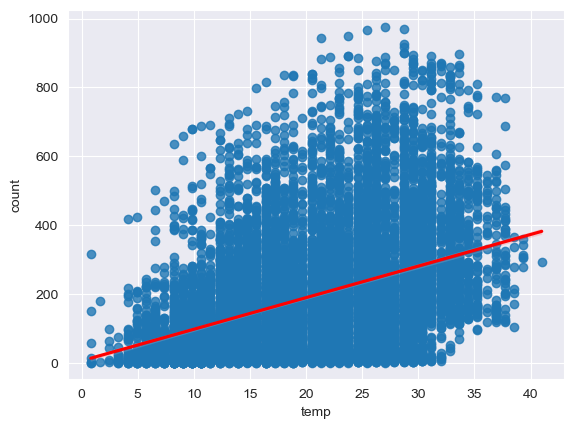

In [76]:
import seaborn as sns

sns.regplot(x='temp',
            y='count',
            data=train,
            line_kws={'color': 'red'})

<Axes: xlabel='hour', ylabel='count'>

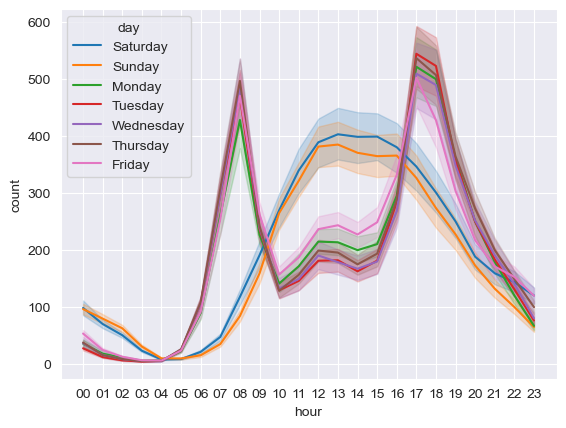

In [77]:
sns.lineplot(data=train,x='hour', y='count', hue='day')

In [78]:
test = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')

In [79]:
test['year'] = test['datetime'].str[0:4] # extract first 4 characters to make year column
test['month'] = test['datetime'].str[5:7] # extract characters 5:7
test['hour'] = test['datetime'].str[11:13] # extract characters 11:13
test['day'] = pd.to_datetime(test['datetime']).dt.day_name()

In [80]:
my_model = (smf.ols('np.log(count) ~ '
                   'I(temp**2)  '
                   '+ I(temp**3)'
                   '+ temp '
                   '* humidity '
                   '+ year '
                   '+ C(season) '
                   '+ hour'
                   '* day'
                   '+ windspeed'
                   '+C(weather)'
                   ,train
                    )
            .fit()
            #.summary()
            )

In [81]:
test['count'] = np.exp(my_model.predict(test))
submission = test[['datetime', 'count']]
submission.to_csv('C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/parker_python.csv',index=False)

In [82]:
test['datetime'].head(1)

0    2011-01-20 00:00:00
Name: datetime, dtype: object

In [83]:
train['log_wind'] = np.log1p(train['windspeed'])
test['log_wind']  = np.log1p(test['windspeed'])

# comfort index — heat + humidity combined stress
train['discomfort'] = train['atemp'] * train['humidity']
test['discomfort']  = test['atemp']  * test['humidity']

# cold & wet penalty
train['cold_wet'] = (1 - train['atemp']) * train['humidity']
test['cold_wet']  = (1 - test['atemp'])  * test['humidity']

# TRAIN
train['datetime'] = pd.to_datetime(train['datetime'])
train['day'] = train['datetime'].dt.day_name()

# TEST
test['datetime'] = pd.to_datetime(test['datetime'])
test['day'] = test['datetime'].dt.day_name()

train['hour'] = train['datetime'].dt.hour
test['hour']  = test['datetime'].dt.hour

hour_avg = train.groupby('hour')['count'].mean()

train['hour_avg'] = train['hour'].map(hour_avg)
test['hour_avg']  = test['hour'].map(hour_avg)

# ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']
my_model = smf.ols(
    'np.log(count) ~ '
    'I(temp**2) + I(temp**3) '
    '+ temp * humidity '
    '+ discomfort * cold_wet '
    '+ cold_wet '
    '+ year '
    '+ C(season) '
    '+ hour * day * workingday '
    '+ log_wind '
    '+ atemp '
    '+ C(weather) '
    '+ season * weather * temp '
    '+ weather * humidity '
    '+ atemp / temp '
    '+ weather / humidity '
    #'+ day'
    #'+ hour_avg'
    ,
    data=train
).fit()

test['count'] = np.exp(my_model.predict(test))
submission = test[['datetime', 'count']]
submission.to_csv('C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/parker_python_2.csv',index=False)

In [84]:
train['log_wind'] = np.log1p(train['windspeed'])
test['log_wind']  = np.log1p(test['windspeed'])

formula = (
    'I(temp**2) + I(temp**3) + temp * humidity '
    '+ year '
    '+ C(season) '
    '+ hour * day * workingday '
    '+ log_wind '
    '+ atemp '
    '+ C(weather) '
    '+ weather * humidity'
)

model_reg    = smf.ols(f'np.log(registered + 1) ~ {formula}', data=train).fit()
model_casual = smf.ols(f'np.log(casual + 1) ~ {formula}', data=train).fit()

test['count'] = (
    np.exp(model_reg.predict(test)) +
    np.exp(model_casual.predict(test))
)

submission = test[['datetime', 'count']]
submission.to_csv('...parker_python_3.csv', index=False)

In [85]:
import pandas as pd
from statsmodels.formula.api import ols
import numpy as np
train = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/train.csv')

train['year'] = train['datetime'].str[0:4]
train['month'] = train['datetime'].str[5:7]
train['hour'] = train['datetime'].str[11:13]
train['day'] = pd.to_datetime(train['datetime']).dt.day_name()

test = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')
test['year'] = test['datetime'].str[0:4]
test['month'] = test['datetime'].str[5:7]
test['hour'] = test['datetime'].str[11:13]
test['day'] = pd.to_datetime(test['datetime']).dt.day_name()

train['log_wind'] = np.log1p(train['windspeed'])
test['log_wind']  = np.log1p(test['windspeed'])

# comfort index — heat + humidity combined stress
train['discomfort'] = train['atemp'] * train['humidity']
test['discomfort']  = test['atemp']  * test['humidity']

# cold & wet penalty
train['cold_wet'] = (1 - train['atemp']) * train['humidity']
test['cold_wet']  = (1 - test['atemp'])  * test['humidity']

# TRAIN
train['datetime'] = pd.to_datetime(train['datetime'])
train['day'] = train['datetime'].dt.day_name()

# TEST
test['datetime'] = pd.to_datetime(test['datetime'])
test['day'] = test['datetime'].dt.day_name()

train['hour'] = train['datetime'].dt.hour
test['hour']  = test['datetime'].dt.hour

hour_avg = train.groupby('hour')['count'].mean()

train['hour_avg'] = train['hour'].map(hour_avg)
test['hour_avg']  = test['hour'].map(hour_avg)

my_model = ols(    'np.log(count) ~ '
    'I(temp**2) + I(temp**3) '
    '+ temp * humidity '
    '+ discomfort * cold_wet '
    '+ cold_wet '
    '+ year '
    '+ C(season) '
    '+ hour * day * workingday '
    # '+ log_wind '
    # '+ atemp '
    # '+ C(weather) '
    # '+ season * weather * temp '
    # '+ weather * humidity '
    # '+ atemp / temp '
    # '+ weather / humidity '
    # #'+ day'
    # #'+ hour_avg'
, train).fit()
test['count'] = np.exp(my_model.predict(test))
submission = test[['datetime', 'count']]
submission.to_csv('C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/parker_python_3.csv',index=False)

In [87]:
# model works
test = pd.read_csv('https://raw.githubusercontent.com/blacktreeM/econ/refs/heads/main/test.csv')
test['year'] = test['datetime'].str[0:4] # extract first 4 characters to make year column
test['month'] = test['datetime'].str[5:7] # extract characters 5:7
test['hour'] = test['datetime'].str[11:13] # extract characters 11:13
test['day'] = pd.to_datetime(test['datetime']).dt.day_name()

my_model = smf.ols(
    'np.log(count) ~ '
    'atemp + I(atemp**2) + I(atemp**3) '
    '+ humidity + I(humidity**2) '        # humidity also has a sweet spot
    '+ log_wind '
    '+ year '
    '+ C(month) '                          # replaces C(season)
    '+ C(weather) '
    '+ hour_sin * day + hour_cos * day '   # replaces hour * day
    '+ hour_sin * workingday '             # commute spike
    '+ hour_cos * workingday ',
    data=train
).fit()

test['count'] = np.exp(my_model.predict(test))
submission = test[['datetime', 'count']]
submission.to_csv('C:/Users/tyler/OneDrive/Documents/GitHub/work_to_show/Classes Spring 2026/Econometrics/parker_python_2.csv',index=False)

PatsyError: Error evaluating factor: NameError: name 'hour_sin' is not defined
    np.log(count) ~ atemp + I(atemp**2) + I(atemp**3) + humidity + I(humidity**2) + log_wind + year + C(month) + C(weather) + hour_sin * day + hour_cos * day + hour_sin * workingday + hour_cos * workingday
                                                                                                                              ^^^^^^^^